<a href="https://colab.research.google.com/github/jrebull/MIAAD_IngenieraDatos/blob/main/Actividad_Transformaciones_PySpark_NSLKDD_JavierRebull.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table width="100%" style="border:none;">
<tr style="border:none;">
<td width="20%" align="center" style="border:none;">
<img src="https://www.uacj.mx/images/UACJ-LOGO.png" width="120" alt="UACJ"/>
</td>
<td width="60%" align="center" style="border:none;">
<h1 style="color:#002B5C; margin-bottom:4px;">Universidad Autónoma de Ciudad Juárez</h1>
<h3 style="color:#0d1b2a; margin-top:0;">Maestría en Inteligencia Artificial y Analítica de Datos</h3>
<h3 style="color:#C8962E; margin-top:0;">Ingeniería de Datos Avanzada</h3>
</td>
<td width="20%" align="center" style="border:none;">
<img src="https://iili.io/qrfnJLv.jpg" width="110" alt="Javier Rebull"/>
</td>
</tr>
</table>

<hr style="border: 2px solid #002B5C;"/>

<h2 align="center" style="color:#002B5C;">Actividad Práctica: Transformaciones en PySpark</h2>
<h3 align="center" style="color:#0d1b2a;">Análisis del dataset NSL-KDD · Detección de Intrusiones de Red</h3>

<table width="100%" style="border:none;">
<tr style="border:none;">
<td width="50%" style="border:none;">
<b>Estudiante:</b> Javier Augusto Rebull Saucedo<br>
<b>Matrícula:</b> 263483<br>
<b>Programa:</b> MIAAD
</td>
<td width="50%" style="border:none;">
<b>Docente:</b> Dr. Vicente García Jiménez<br>
<b>Semestre:</b> 2026-1<br>
<b>Entorno:</b> Google Colab · PySpark 3.5+
</td>
</tr>
</table>

<hr style="border: 1px solid #C8962E;"/>

## Objetivo de la práctica

Aplicar las principales transformaciones sobre `DataFrame` de PySpark vistas en clase, utilizando el conjunto de datos NSL-KDD relacionado con detección de intrusiones de red. La práctica integra los temas de los tres notebooks de clase:

1. Transformaciones básicas: `select`, `filter`, `withColumn`, `orderBy`.
2. Operaciones sobre columnas: `col`, expresiones aritméticas, alias.
3. Pseudo-conjuntos y agregaciones: `distinct`, `groupBy`, `count`, `avg`.

## Actividades a desarrollar

| # | Actividad | Transformación principal |
|---|-----------|--------------------------|
| 1 | Cargar el dataset en un `DataFrame` de PySpark | `spark.read.csv` con `inferSchema` |
| 2 | Mostrar número de filas, columnas y primeras 10 filas | `count`, `len(columns)`, `show(10)` |
| 3 | Seleccionar `protocol_type`, `service`, `src_bytes`, `dst_bytes`, `label` | `select` |
| 4 | Filtrar registros con `protocol_type = 'tcp'` y `src_bytes > 1000` | `filter` con condiciones combinadas |
| 5 | Crear columna `total_bytes = src_bytes + dst_bytes` | `withColumn` |
| 6 | Ordenar de mayor a menor por `total_bytes` | `orderBy` con `desc()` |
| 7 | Mostrar valores únicos de `protocol_type` | `select().distinct()` |
| 8 | Agrupar por `protocol_type` y contar registros | `groupBy().count()` |
| 9 | Agrupar por `label` y calcular promedio de `src_bytes` | `groupBy().avg()` |

## Nota sobre el archivo de datos

El archivo `NSL_KDD.csv` provisto en Moodle presenta un **encabezado desalineado** respecto a los datos: incluye 42 nombres comenzando por `duration` mientras que cada fila trae 42 valores donde el primero es ya `protocol_type`. La sección 1.2 detecta esta anomalía y aplica una **reasignación de nombres** que deja la columna de etiquetas con el nombre `label` requerido por la rúbrica.

##### Link GitHub https://github.com/jrebull/MIAAD_IngenieraDatos/blob/main/Actividad_Transformaciones_PySpark_NSLKDD_JavierRebull.ipynb

---

## 0 - Instalación y configuración del entorno

Esta sección verifica la disponibilidad de PySpark, descarga el archivo CSV desde Google Drive e inicializa la `SparkSession`. **Ejecuta estas celdas en orden una sola vez al inicio de la sesión de Colab.**

### 0.1 - Verificación e instalación de PySpark

Esta celda verifica si la librería PySpark está disponible y, en caso contrario, la instala desde PyPI. El notebook es compatible con **PySpark 3.5+ y con la versión preinstalada en Colab (actualmente 4.0.2)**, ya que el API de `DataFrame` utilizado en esta práctica es estable entre ambas versiones mayores.

In [1]:
# ============================================================
# VERIFICAR SI PYSPARK ESTÁ INSTALADO
# ============================================================

try:
    import pyspark

    print('PySpark ya está instalado.')
    print(f'Versión instalada: {pyspark.__version__}')

except ImportError:

    print('PySpark no está instalado.')
    print('Instalando PySpark...\n')

    # Instalación silenciosa para mantener limpia la salida en Colab
    # (compatible con PySpark 3.5+ y 4.x; usamos la versión disponible en Colab)
    !pip install pyspark -q

    # Verificación posterior a la instalación
    import pyspark

    print('PySpark instalado correctamente.')
    print(f'Versión instalada: {pyspark.__version__}')

# ============================================================
# MOSTRAR VERSIÓN DESDE TERMINAL
# ============================================================

print('\nInformación desde terminal:')
!pyspark --version

PySpark ya está instalado.
Versión instalada: 4.0.2

Información desde terminal:
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /___/ .__/\_,_/_/ /_/\_\   version 4.0.2
      /_/
                        
Using Scala version 2.13.16, OpenJDK 64-Bit Server VM, 17.0.18
Branch HEAD
Compiled by user runner on 2026-02-02T08:08:13Z
Revision 7cc3b9bcdaab8c923f23cdbc9ce922530e1becf1
Url https://github.com/apache/spark
Type --help for more information.


### 0.2 - Importación de librerías y creación de la `SparkSession`

Para mantener el código limpio y reproducible, todas las importaciones necesarias se concentran en una sola celda al inicio del notebook. Esto evita errores de tipo `NameError` cuando se ejecutan celdas fuera de orden.

Se importan:

- `os` para interactuar con el sistema de archivos.
- `SparkSession` como punto de entrada al motor Spark.
- `functions` (alias `F`) para acceder a las funciones SQL nativas de PySpark.
- `desc` para indicar orden descendente en los `orderBy`.
- `IPython.display` para mostrar contenido enriquecido en Colab.

La `SparkSession` se configura con un nombre de aplicación descriptivo y desactiva la barra de progreso para obtener una salida más limpia en el entorno de notebook.


In [2]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

# Librería estándar para interactuar con el sistema operativo
import os

# Clase principal para crear una sesión de Spark
from pyspark.sql import SparkSession

# Módulo de funciones SQL de PySpark (alias F por convención)
from pyspark.sql import functions as F

# Función para indicar orden descendente en orderBy
from pyspark.sql.functions import desc, col, avg, count

# Utilidades para visualización en Google Colab
from IPython.display import display, HTML

# ============================================================
# CREACIÓN DE LA SPARK SESSIONx
# ============================================================

spark = (
    SparkSession.builder

    # Nombre de la aplicación que aparecerá en la interfaz de Spark
    .appName('TransformacionesPySpark_NSLKDD')

    # Desactiva la barra de progreso para una salida más limpia
    .config('spark.ui.showConsoleProgress', 'false')

    # Crea la sesión o recupera una existente
    .getOrCreate()
)

# Reduce el ruido del log mostrando únicamente errores
spark.sparkContext.setLogLevel('ERROR')

# ============================================================
# VERIFICAR LA SESIÓN DE SPARK
# ============================================================

print(f'SparkSession activa - versión Spark: {spark.version}')
print(f'Nombre de la aplicación: {spark.sparkContext.appName}')


SparkSession activa - versión Spark: 4.0.2
Nombre de la aplicación: TransformacionesPySpark_NSLKDD


### 0.3 - Descarga del archivo NSL_KDD.csv con `gdown`

`gdown.download_folder()` descarga todo el contenido de la carpeta indicada a un directorio local del entorno de Colab. El archivo `NSL_KDD.csv` queda disponible en `/content/MIIAD_IDA/`.

In [3]:
# ============================================================
# DESCARGA DEL DATASET DESDE GOOGLE DRIVE CON gdown
# ============================================================

# Asegurar la versión más reciente de gdown
# (versiones antiguas tienen bugs con download_folder)
!pip install gdown --upgrade -q

import gdown
import os

# URL pública de la carpeta del curso en Google Drive
folder_url = 'https://drive.google.com/drive/folders/1rii2mWXPm0wZrZghG1GJt_qrk8ptUTPG?usp=sharing'

# Descargar todo el contenido de la carpeta a /content/MIIAD_IDA
gdown.download_folder(
    url=folder_url,
    output='/content/MIIAD_IDA',
    quiet=False,
    use_cookies=False
)

# Listar el contenido descargado para verificación
print('\nContenido descargado en /content/MIIAD_IDA:')
for archivo in sorted(os.listdir('/content/MIIAD_IDA')):
    ruta = os.path.join('/content/MIIAD_IDA', archivo)
    tamaño_mb = os.path.getsize(ruta) / (1024 * 1024)
    print(f'  - {archivo} ({tamaño_mb:.2f} MB)')

# Definir la ruta del archivo CSV para las siguientes celdas
ruta_csv = '/content/MIIAD_IDA/NSL_KDD.csv'

# Verificación final
if not os.path.exists(ruta_csv):
    raise FileNotFoundError(
        f'No se encontró NSL_KDD.csv en {ruta_csv}. '
        'Revisa el contenido listado arriba.'
    )

print(f'\nArchivo listo para cargar: {ruta_csv}')

Retrieving folder contents


Processing file 1xwSBMDZfOpqBYtzQuqC7zbg_pX9HzWVg NSL_KDD.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1xwSBMDZfOpqBYtzQuqC7zbg_pX9HzWVg
To: /content/MIIAD_IDA/NSL_KDD.csv
100%|██████████| 2.52M/2.52M [00:00<00:00, 6.35MB/s]


Contenido descargado en /content/MIIAD_IDA:
  - NSL_KDD.csv (2.40 MB)

Archivo listo para cargar: /content/MIIAD_IDA/NSL_KDD.csv



Download completed


---

## 1 - Carga del dataset y exploración inicial

### 1.1 - Acerca del conjunto de datos NSL-KDD

El dataset **NSL-KDD** es una versión refinada del clásico KDD'99 ampliamente utilizado en la investigación de **Intrusion Detection Systems (IDS)**. Contiene registros de conexiones de red etiquetadas como tráfico normal o como diferentes tipos de ataque (DoS, Probe, R2L, U2R).

Cada registro describe una conexión TCP/UDP/ICMP mediante 41 atributos más una etiqueta de clase. Las columnas relevantes para esta práctica son:

| Columna | Tipo | Descripción |
|---------|------|-------------|
| `protocol_type` | string | Protocolo de transporte: `tcp`, `udp` o `icmp` |
| `service` | string | Servicio de red destino (http, ftp, smtp, etc.) |
| `src_bytes` | int | Número de bytes enviados desde el origen al destino |
| `dst_bytes` | int | Número de bytes enviados desde el destino al origen |
| `label` | string | Etiqueta de clase: `normal` o tipo de ataque |

### 1.2 - Carga del archivo CSV

El esquema se infiere automáticamente con la opción `inferSchema='true'`, evitando definir manualmente un `StructType`. La opción `header='true'` indica que la primera fila contiene los nombres de columna.


In [4]:
# ============================================================
# CARGA DEL CONJUNTO DE DATOS NSL-KDD
# ============================================================

# Cargar el archivo CSV en un DataFrame de PySpark
df_raw = (
    spark.read

    # Indica que la primera fila contiene los encabezados
    .option('header', 'true')

    # Inferir automáticamente el esquema (tipos de datos por columna)
    .option('inferSchema', 'true')

    # Cargar el archivo desde la ruta local descargada con gdown
    .csv(ruta_csv)
)

print('Dataset NSL-KDD cargado correctamente desde el archivo descargado.')

Dataset NSL-KDD cargado correctamente desde el archivo descargado.


#### Validación post-carga: verificación de la integridad del archivo

Antes de aplicar cualquier transformación, validamos que la carga sea coherente. En este caso, al inspeccionar el archivo `NSL_KDD.csv` provisto en el Moodle detecto una anomalía mayor: **el encabezado del archivo está desalineado respecto a los datos**.

Concretamente, el header lista 42 columnas comenzando por `duration`, pero los datos solo traen 42 valores donde el primero es ya `protocol_type` (faltando `duration` al inicio). Como consecuencia, todos los nombres del header quedan desplazados una posición y la columna que la rúbrica pide se llame `label` aparece nombrada como `class` (y además recibe los valores numéricos del campo `difficulty`).

**Comportamiento esperado tras el ajuste:**

| Posición | Antes (header del archivo) | Después (renombrado) |
|----------|----------------------------|-----------------------|
| 1 | `duration` (recibe `'tcp'`) | `protocol_type` (recibe `'tcp'`) |
| 2 | `protocol_type` (recibe `'private'`) | `service` (recibe `'private'`) |
| 3 | `service` (recibe `'REJ'`) | `flag` (recibe `'REJ'`) |
| 4 | `flag` (recibe `0`) | `src_bytes` (recibe `0`) |
| 41 | `dst_host_srv_rerror_rate` (recibe `'neptune'`) | `label` (recibe `'neptune'`) |
| 42 | `class` (recibe `21`) | `difficulty` (recibe `21`) |

La siguiente celda detecta el problema, aplica los nombres correctos y verifica que los tipos de datos queden alineados (`src_bytes` y `dst_bytes` numéricos, `label` string).

In [5]:
# ============================================================
# VALIDACIÓN Y CORRECCIÓN DEL HEADER DESALINEADO
# ============================================================

# Si la columna llamada 'duration' no es numérica, el header
# está desplazado y la columna en la posición 1 es realmente protocol_type.
tipo_duration = dict(df_raw.dtypes).get('duration', '')
header_desalineado = tipo_duration in ('string',) or 'class' in df_raw.columns

if header_desalineado:
    print('Anomalía detectada: el encabezado está desalineado con los datos.')
    print(f'  - Tipo inferido para "duration": {tipo_duration}')
    print(f'  - Columna de etiqueta presente como: "class" (debería ser "label")')
    print('Aplicando corrección: reasignación de los 42 nombres reales del archivo.\n')

    # Nombres reales del archivo NSL_KDD.csv del Moodle (42 columnas).
    # Diferencia respecto al estándar NSL-KDD: este archivo NO incluye 'duration'.
    nombres_reales = [
        'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
        'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
        'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
        'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
        'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
        'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
        'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
        'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
        'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
        'label', 'difficulty'
    ]

    # Recargar saltando el header defectuoso y aplicar los nombres correctos
    df_raw = (
        spark.read
        .option('header', 'true')          # consume y descarta la fila de header
        .option('inferSchema', 'true')
        .csv(ruta_csv)
        .toDF(*nombres_reales)             # sobrescribe los nombres con los correctos
    )

    print(f'Nombres reasignados a las {len(df_raw.columns)} columnas.')
else:
    # Cualquier dataset bien formado pasa por aquí.
    # Como precaución, limpiamos espacios en blanco en los nombres.
    df_raw = df_raw.toDF(*[c.strip() for c in df_raw.columns])
    print('Header íntegro: no se requiere reasignación.')

# Validación final: las columnas requeridas por la actividad deben existir
columnas_requeridas = {'protocol_type', 'service', 'src_bytes', 'dst_bytes', 'label'}
faltantes = columnas_requeridas - set(df_raw.columns)

if faltantes:
    raise ValueError(f'Faltan columnas requeridas tras la corrección: {faltantes}')

print('\nValidación OK: las 5 columnas requeridas por la actividad están presentes.')
print(f'Columnas finales del DataFrame ({len(df_raw.columns)}): {df_raw.columns}')


Anomalía detectada: el encabezado está desalineado con los datos.
  - Tipo inferido para "duration": string
  - Columna de etiqueta presente como: "class" (debería ser "label")
Aplicando corrección: reasignación de los 42 nombres reales del archivo.

Nombres reasignados a las 42 columnas.

Validación OK: las 5 columnas requeridas por la actividad están presentes.
Columnas finales del DataFrame (42): ['protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_d

### 1.3 - Exploración inicial del DataFrame

Antes de aplicar cualquier transformación, conviene inspeccionar:

- el **esquema** inferido por Spark (tipos de datos asignados a cada columna),
- el **número total de filas** del dataset,
- el **número total de columnas**, y
- las **primeras 10 filas** mediante `show()`.

Esta exploración inicial corresponde a las primeras tres actividades solicitadas en la práctica.


In [6]:
# ============================================================
# ESQUEMA DEL DATAFRAME (TIPOS DE DATOS INFERIDOS)
# ============================================================

print('Esquema inferido por Spark:\n')
df_raw.printSchema()


Esquema inferido por Spark:

root
 |-- protocol_type: string (nullable = true)
 |-- service: string (nullable = true)
 |-- flag: string (nullable = true)
 |-- src_bytes: integer (nullable = true)
 |-- dst_bytes: integer (nullable = true)
 |-- land: integer (nullable = true)
 |-- wrong_fragment: integer (nullable = true)
 |-- urgent: integer (nullable = true)
 |-- hot: integer (nullable = true)
 |-- num_failed_logins: integer (nullable = true)
 |-- logged_in: integer (nullable = true)
 |-- num_compromised: integer (nullable = true)
 |-- root_shell: integer (nullable = true)
 |-- su_attempted: integer (nullable = true)
 |-- num_root: integer (nullable = true)
 |-- num_file_creations: integer (nullable = true)
 |-- num_shells: integer (nullable = true)
 |-- num_access_files: integer (nullable = true)
 |-- num_outbound_cmds: integer (nullable = true)
 |-- is_host_login: integer (nullable = true)
 |-- is_guest_login: integer (nullable = true)
 |-- count: integer (nullable = true)
 |-- srv_c

**Análisis:** la carga inferencial reconoce el archivo como CSV válido y crea un DataFrame distribuido. El mensaje confirma que Spark pudo abrir el archivo y mapear el esquema sin errores estructurales, pero la sección siguiente verifica si la semántica del header coincide con los datos.

In [7]:
# ============================================================
# ACTIVIDAD 2.a - NÚMERO TOTAL DE FILAS
# ============================================================

# count() es una acción que dispara la ejecución del DAG completo
total_filas = df_raw.count()

print(f'Número total de filas: {total_filas:,}')


Número total de filas: 18,035


**Análisis:** 18,035 flujos de red constituyen un volumen razonable para una práctica académica de transformaciones, pero recordemos que en un entorno productivo de IDS estos volúmenes se generan en cuestión de minutos. Spark está diseñado para escalar este mismo código a miles de millones de registros sin cambios sintácticos.

In [8]:
# ============================================================
# ACTIVIDAD 2.b - NÚMERO TOTAL DE COLUMNAS
# ============================================================

# columns devuelve una lista Python con los nombres de las columnas
total_columnas = len(df_raw.columns)

print(f'Número total de columnas: {total_columnas}')

# Listado de todas las columnas para verificación
print('\nNombres de las columnas:')
for i, c in enumerate(df_raw.columns, 1):
    print(f'  {i:>2}. {c}')


Número total de columnas: 42

Nombres de las columnas:
   1. protocol_type
   2. service
   3. flag
   4. src_bytes
   5. dst_bytes
   6. land
   7. wrong_fragment
   8. urgent
   9. hot
  10. num_failed_logins
  11. logged_in
  12. num_compromised
  13. root_shell
  14. su_attempted
  15. num_root
  16. num_file_creations
  17. num_shells
  18. num_access_files
  19. num_outbound_cmds
  20. is_host_login
  21. is_guest_login
  22. count
  23. srv_count
  24. serror_rate
  25. srv_serror_rate
  26. rerror_rate
  27. srv_rerror_rate
  28. same_srv_rate
  29. diff_srv_rate
  30. srv_diff_host_rate
  31. dst_host_count
  32. dst_host_srv_count
  33. dst_host_same_srv_rate
  34. dst_host_diff_srv_rate
  35. dst_host_same_src_port_rate
  36. dst_host_srv_diff_host_rate
  37. dst_host_serror_rate
  38. dst_host_srv_serror_rate
  39. dst_host_rerror_rate
  40. dst_host_srv_rerror_rate
  41. label
  42. difficulty


**Análisis:** las 42 columnas reflejan la riqueza semántica del NSL-KDD: 40 features técnicas (volúmenes de bytes, tasas de error, conteos por host y servicio), la etiqueta `label` y el indicador `difficulty`. Esta alta dimensionalidad es típica de los datasets de ciberseguridad y justifica la necesidad de aplicar `select()` para enfocarse en las variables relevantes.

In [9]:
# ============================================================
# ACTIVIDAD 2.c - PRIMERAS 10 FILAS DEL DATAFRAME
# ============================================================

# show() con truncado por defecto para que la salida sea legible
# (NSL-KDD tiene 42+ columnas; truncate=False produciría líneas demasiado anchas)
print('Primeras 10 filas del DataFrame original:\n')
df_raw.show(10)

# Vista alternativa con las columnas relevantes para esta práctica,
# útil para verificar que los encabezados se cargaron correctamente
print('\nVista de las columnas que utilizaremos en la práctica:\n')
df_raw.select('protocol_type', 'service', 'src_bytes', 'dst_bytes', 'label').show(10, truncate=False)


Primeras 10 filas del DataFrame original:

+-------------+-------+----+---------+---------+----+--------------+------+---+-----------------+---------+---------------+----------+------------+--------+------------------+----------+----------------+-----------------+-------------+--------------+-----+---------+-----------+---------------+-----------+---------------+-------------+-------------+------------------+--------------+------------------+----------------------+----------------------+---------------------------+---------------------------+--------------------+------------------------+--------------------+------------------------+------------+----------+
|protocol_type|service|flag|src_bytes|dst_bytes|land|wrong_fragment|urgent|hot|num_failed_logins|logged_in|num_compromised|root_shell|su_attempted|num_root|num_file_creations|num_shells|num_access_files|num_outbound_cmds|is_host_login|is_guest_login|count|srv_count|serror_rate|srv_serror_rate|rerror_rate|srv_rerror_rate|same_srv_rate

**Análisis:** la muestra revela patrones inmediatos: predominio del protocolo TCP, servicios variados (`private`, `telnet`, `http`, `ftp`) y una distribución amplia en `src_bytes` (de 0 hasta 14,515 en estas 10 filas). Las primeras dos filas con `src_bytes = dst_bytes = 0` y label `neptune` corresponden a intentos de conexión sin transferencia de datos, un patrón característico de ataques SYN flood.

---

## 2 - Selección de columnas con `select()`

La transformación `select()` realiza una **proyección de columnas** sobre el DataFrame, es decir, conserva únicamente las columnas indicadas. Funciona de manera equivalente a la cláusula `SELECT` de SQL.

Para esta actividad seleccionamos cinco columnas del NSL-KDD que son relevantes para analizar el comportamiento del tráfico de red:

- `protocol_type`: protocolo de transporte utilizado.
- `service`: servicio de red destino.
- `src_bytes`: bytes enviados desde el origen.
- `dst_bytes`: bytes enviados desde el destino.
- `label`: etiqueta de clase (normal o tipo de ataque).

En PySpark, **toda transformación retorna un nuevo DataFrame** sin modificar el original (inmutabilidad), así que asignamos el resultado a `df_seleccion`.


In [10]:
# ============================================================
# ACTIVIDAD 3 - SELECCIÓN DE COLUMNAS
# ============================================================

# Lista de columnas a proyectar
columnas_objetivo = ['protocol_type', 'service', 'src_bytes', 'dst_bytes', 'label']

# Aplicar select para crear un nuevo DataFrame con solo esas columnas
df_seleccion = df_raw.select(*columnas_objetivo)

print('DataFrame con las columnas seleccionadas:\n')
df_seleccion.show(10, truncate=False)

print(f'Filas conservadas: {df_seleccion.count():,}')
print(f'Columnas conservadas: {len(df_seleccion.columns)} -> {df_seleccion.columns}')


DataFrame con las columnas seleccionadas:

+-------------+-------+---------+---------+------------+
|protocol_type|service|src_bytes|dst_bytes|label       |
+-------------+-------+---------+---------+------------+
|tcp          |private|0        |0        |neptune     |
|tcp          |private|0        |0        |neptune     |
|tcp          |telnet |0        |15       |mscan       |
|tcp          |http   |267      |14515    |normal      |
|tcp          |telnet |129      |174      |guess_passwd|
|tcp          |http   |327      |467      |normal      |
|tcp          |ftp    |26       |157      |guess_passwd|
|tcp          |telnet |0        |0        |mscan       |
|tcp          |private|0        |0        |neptune     |
|tcp          |telnet |0        |0        |neptune     |
+-------------+-------+---------+---------+------------+
only showing top 10 rows
Filas conservadas: 18,035
Columnas conservadas: 5 -> ['protocol_type', 'service', 'src_bytes', 'dst_bytes', 'label']


**Análisis:** la proyección reduce el DataFrame de 42 a 5 columnas conservando las 18,035 filas. Esta operación no implica costo de cómputo significativo en Spark porque es una transformación perezosa: el plan físico simplemente registra que solo se leerán esas 5 columnas cuando se materialice el resultado.

---

## 3 - Filtrado de registros con `filter()`

La transformación `filter()` (equivalente a `where()`) conserva únicamente las filas que cumplen una condición lógica. En PySpark las condiciones se expresan como objetos `Column` y pueden combinarse con los operadores:

- `&` para AND lógico
- `|` para OR lógico
- `~` para NOT lógico

> **Importante:** cada condición debe ir entre paréntesis, ya que `&` y `|` tienen menor precedencia que los operadores de comparación (`==`, `>`, `<`).

Para esta actividad filtramos las conexiones que cumplan **ambas condiciones simultáneamente**:

- protocolo de transporte TCP, y
- más de 1000 bytes enviados desde el origen.

Este filtro es útil porque las conexiones TCP con alto volumen saliente son patrones típicos de transferencias de archivos legítimas o, en su caso, de tráfico anómalo (exfiltración de datos).


In [11]:
# ============================================================
# ACTIVIDAD 4 - FILTRADO POR PROTOCOLO Y BYTES DE ORIGEN
# ============================================================

# Filtro combinado: protocol_type = 'tcp' AND src_bytes > 1000
df_filtrado = df_seleccion.filter(
    (F.col('protocol_type') == 'tcp') &
    (F.col('src_bytes') > 1000)
)

# Contar cuántos registros cumplen ambas condiciones
filas_filtradas = df_filtrado.count()

print(f'Registros que cumplen las condiciones: {filas_filtradas:,}')
print(f'Porcentaje sobre el total: {(filas_filtradas / total_filas) * 100:.2f}%\n')

print('Muestra del DataFrame filtrado:\n')
df_filtrado.show(10, truncate=False)


Registros que cumplen las condiciones: 1,552
Porcentaje sobre el total: 8.61%

Muestra del DataFrame filtrado:

+-------------+--------+---------+---------+-----------+
|protocol_type|service |src_bytes|dst_bytes|label      |
+-------------+--------+---------+---------+-----------+
|tcp          |http    |76944    |1        |apache2    |
|tcp          |ftp_data|283618   |0        |warezmaster|
|tcp          |http    |72564    |0        |apache2    |
|tcp          |smtp    |2599     |293      |mailbomb   |
|tcp          |smtp    |4030     |332      |normal     |
|tcp          |http    |72564    |0        |apache2    |
|tcp          |http    |54540    |8314     |back       |
|tcp          |smtp    |1376     |343      |normal     |
|tcp          |smtp    |1500     |332      |normal     |
|tcp          |smtp    |1710     |366      |normal     |
+-------------+--------+---------+---------+-----------+
only showing top 10 rows


---

## 4 - Creación de la columna `total_bytes` con `withColumn()`

La transformación `withColumn(nombre, expresion)` agrega una nueva columna al DataFrame o reemplaza una existente. La expresión puede ser cualquier operación sobre objetos `Column`: aritmética, lógica, llamadas a funciones SQL, etc.

Definimos la columna **`total_bytes`** como la suma de los bytes enviados en ambas direcciones de la conexión:

$$\text{total\_bytes} = \text{src\_bytes} + \text{dst\_bytes}$$

Esta métrica resume el **volumen total transferido** durante la conexión y será la base del ordenamiento siguiente.


In [12]:
# ============================================================
# ACTIVIDAD 5 - CREAR LA COLUMNA total_bytes
# ============================================================

# withColumn agrega o reemplaza una columna usando una expresión Column
df_con_total = df_filtrado.withColumn(
    'total_bytes',
    F.col('src_bytes') + F.col('dst_bytes')
)

print('DataFrame con la nueva columna total_bytes:\n')
df_con_total.show(10, truncate=False)

# Verificación del esquema actualizado
print('Esquema actualizado:')
df_con_total.printSchema()


DataFrame con la nueva columna total_bytes:

+-------------+--------+---------+---------+-----------+-----------+
|protocol_type|service |src_bytes|dst_bytes|label      |total_bytes|
+-------------+--------+---------+---------+-----------+-----------+
|tcp          |http    |76944    |1        |apache2    |76945      |
|tcp          |ftp_data|283618   |0        |warezmaster|283618     |
|tcp          |http    |72564    |0        |apache2    |72564      |
|tcp          |smtp    |2599     |293      |mailbomb   |2892       |
|tcp          |smtp    |4030     |332      |normal     |4362       |
|tcp          |http    |72564    |0        |apache2    |72564      |
|tcp          |http    |54540    |8314     |back       |62854      |
|tcp          |smtp    |1376     |343      |normal     |1719       |
|tcp          |smtp    |1500     |332      |normal     |1832       |
|tcp          |smtp    |1710     |366      |normal     |2076       |
+-------------+--------+---------+---------+-----------+--

**Análisis:** solo el **8.61% del tráfico** (1,552 de 18,035) cumple ambas condiciones. La muestra revela que dentro de este subconjunto coexisten ataques de gran volumen (`apache2` con 76,944 bytes, `warezmaster` con 283,618) y tráfico normal con transferencias legítimas (`smtp` con ~1,500 a 4,000 bytes). Este filtro sería el punto de partida natural en un IDS para aislar conexiones candidatas a inspección manual.

---

## 5 - Ordenamiento descendente por `total_bytes`

La transformación `orderBy()` (alias `sort()`) reorganiza las filas según una o más columnas. Por defecto el orden es **ascendente**; para invertirlo se utiliza la función `desc()` o el método `.desc()` sobre el objeto `Column`.

Ordenar de mayor a menor por `total_bytes` permite identificar rápidamente las **conexiones con mayor volumen de datos transferidos**, que en un escenario real serían candidatas a inspección por parte de un analista de ciberseguridad.


In [13]:
# ============================================================
# ACTIVIDAD 6 - ORDENAR DE MAYOR A MENOR POR total_bytes
# ============================================================

# orderBy con desc() para orden descendente
df_ordenado = df_con_total.orderBy(F.col('total_bytes').desc())

print('Top 10 conexiones con mayor volumen total de bytes:\n')
df_ordenado.show(10, truncate=False)


Top 10 conexiones con mayor volumen total de bytes:

+-------------+--------+---------+---------+------+-----------+
|protocol_type|service |src_bytes|dst_bytes|label |total_bytes|
+-------------+--------+---------+---------+------+-----------+
|tcp          |X11     |62825648 |90476    |xlock |62916124   |
|tcp          |X11     |31645608 |207796   |xlock |31853404   |
|tcp          |ftp_data|6291668  |0        |normal|6291668    |
|tcp          |ftp_data|3131464  |0        |normal|3131464    |
|tcp          |ftp_data|2194619  |0        |normal|2194619    |
|tcp          |X11     |13948    |1171108  |normal|1185056    |
|tcp          |X11     |286040   |383476   |normal|669516     |
|tcp          |X11     |39224    |511712   |named |550936     |
|tcp          |ftp_data|501760   |0        |normal|501760     |
|tcp          |ftp_data|501760   |0        |normal|501760     |
+-------------+--------+---------+---------+------+-----------+
only showing top 10 rows


**Análisis:** el esquema actualizado confirma que `total_bytes` se inferió correctamente como `integer`, heredando el tipo de sus operandos. La operación es vectorizada y se ejecuta en paralelo en todas las particiones del DataFrame; con 1.5K registros el costo es trivial, pero con miles de millones de filas esta misma sintaxis aprovecharía todos los cores disponibles del cluster.

---

## 6 - Valores únicos de `protocol_type` con `distinct()`

La transformación `distinct()` elimina filas duplicadas. Combinada con `select('columna')` permite obtener el conjunto de **valores únicos** que aparecen en una columna específica, equivalente al `SELECT DISTINCT` de SQL.

En el dataset NSL-KDD esperamos encontrar tres protocolos de transporte: **TCP**, **UDP** e **ICMP**.


In [14]:
# ============================================================
# ACTIVIDAD 7 - VALORES ÚNICOS DE protocol_type
# ============================================================

# Trabajamos sobre df_raw para obtener todos los protocolos del dataset
# (no solo los del subconjunto filtrado)
df_protocolos_unicos = df_raw.select('protocol_type').distinct()

print('Protocolos de transporte únicos presentes en el dataset:\n')
df_protocolos_unicos.show()

print(f'Cantidad de protocolos distintos: {df_protocolos_unicos.count()}')


Protocolos de transporte únicos presentes en el dataset:

+-------------+
|protocol_type|
+-------------+
|          tcp|
|          udp|
|         icmp|
+-------------+

Cantidad de protocolos distintos: 3


**Análisis:** el resultado es revelador desde la perspectiva de seguridad: las dos conexiones con mayor volumen (62.9 MB y 31.8 MB respectivamente) son ataques `xlock` sobre el servicio X11, lo cual es consistente con el modus operandi de este tipo de exploit. Le siguen transferencias `ftp_data` normales (entre 2 y 6 MB) que representan tráfico legítimo de alto volumen. El contraste entre la conexión #1 (62.9 MB de un ataque) y el resto es de un orden de magnitud, evidenciando lo asimétrica que es la distribución de bytes en el dataset.

---

## 7 - Agrupamiento por `protocol_type` con `count()`

La transformación `groupBy()` agrupa las filas según una o más columnas y devuelve un objeto `GroupedData` sobre el cual se aplican funciones de agregación (`count`, `sum`, `avg`, `max`, `min`, etc.).

Aquí calculamos **cuántos registros existen por cada protocolo de transporte**, lo que da una idea de la composición del tráfico capturado en el dataset.

Para facilitar la lectura, ordenamos el resultado de mayor a menor por la cuenta.


In [15]:
# ============================================================
# ACTIVIDAD 8 - GROUPBY protocol_type CON count()
# ============================================================

df_count_por_protocolo = (
    df_raw
    .groupBy('protocol_type')
    .count()
    .orderBy(F.col('count').desc())
)

print('Conteo de registros por protocolo de transporte:\n')
df_count_por_protocolo.show()


Conteo de registros por protocolo de transporte:

+-------------+-----+
|protocol_type|count|
+-------------+-----+
|          tcp|15136|
|          udp| 2074|
|         icmp|  825|
+-------------+-----+



**Análisis:** los tres protocolos confirman que el dataset cubre toda la pila de transporte de IP: **TCP** (orientado a conexión, usado en HTTP, FTP, SSH), **UDP** (sin conexión, usado en DNS, DHCP, streaming) e **ICMP** (control y diagnóstico, base de ataques como `smurf`). Esta diversidad es lo que permite que el NSL-KDD sea representativo para entrenar modelos de detección genéricos.

---

## 8 - Agrupamiento por `label` con promedio de `src_bytes`

Finalmente, agrupamos las conexiones por su **etiqueta de clase** (`label`) y calculamos el **promedio de bytes enviados desde el origen** (`src_bytes`) para cada categoría.

Para mejorar la legibilidad de la salida:

- Renombramos la columna agregada con `alias('avg_src_bytes')`.
- Redondeamos a dos decimales con `F.round(...)`.
- Ordenamos de mayor a menor promedio.

Este análisis permite comparar el volumen promedio enviado por conexión entre tráfico normal y los distintos tipos de ataque, lo que en un sistema real ayudaría a establecer **umbrales de alerta**.


In [16]:
# ============================================================
# ACTIVIDAD 9 - GROUPBY label CON avg(src_bytes)
# ============================================================

df_avg_por_label = (
    df_raw
    .groupBy('label')

    # Calcular el promedio de src_bytes y renombrar la columna resultante
    .agg(
        F.round(F.avg('src_bytes'), 2).alias('avg_src_bytes'),
        F.count('*').alias('num_registros')
    )

    # Ordenar de mayor a menor promedio
    .orderBy(F.col('avg_src_bytes').desc())
)

print('Promedio de src_bytes y cantidad de registros por etiqueta:\n')

# Mostrar todas las etiquetas (algunas versiones del NSL-KDD tienen 23+)
df_avg_por_label.show(50, truncate=False)


Promedio de src_bytes y cantidad de registros por etiqueta:

+---------------+-------------+-------------+
|label          |avg_src_bytes|num_registros|
+---------------+-------------+-------------+
|xlock          |1.350409943E7|7            |
|warezmaster    |65186.26     |762          |
|rootkit        |54713.2      |10           |
|back           |52894.35     |291          |
|apache2        |38689.75     |591          |
|named          |22001.64     |14           |
|worm           |4209.0       |1            |
|xterm          |3137.91      |11           |
|mailbomb       |2599.0       |221          |
|normal         |2501.93      |7789         |
|buffer_overflow|1867.0       |18           |
|multihop       |1767.83      |12           |
|sendmail       |1698.73      |11           |
|imap           |1352.0       |1            |
|pod            |1341.21      |33           |
|smurf          |909.51       |523          |
|xsnoop         |775.75       |4            |
|httptunnel     |50

**Análisis:** el **83.9% del tráfico es TCP** (15,136 registros), reflejando que la mayoría de servicios atacables en redes corporativas operan sobre este protocolo. UDP representa el 11.5% (2,074) e ICMP solo el 4.6% (825). Esta dominancia condiciona cualquier análisis posterior: los modelos entrenados sobre este dataset tendrán mucha más información sobre patrones de ataque en TCP que en UDP/ICMP, lo que en producción suele requerir técnicas de balanceo o muestreo estratificado.

---

## 9. Dashboard Ejecutivo: Síntesis Visual del Análisis

Para cerrar la práctica, consolido las nueve transformaciones aplicadas en un **dashboard ejecutivo de una sola vista** que sintetiza los hallazgos del análisis NSL-KDD. El dashboard sigue el patrón de un *operations panel* tipo SOC (Security Operations Center) y combina:

- **Indicadores clave (KPIs)**: volumen total, dominancia TCP, diversidad de ataques y volumen máximo por conexión.
- **Distribución por protocolo**: donut con la composición TCP/UDP/ICMP del tráfico.
- **Top etiquetas por frecuencia**: barras horizontales separando tráfico normal (verde) de ataques (rojo).
- **Top etiquetas por volumen promedio**: barras en escala logarítmica con gradiente de severidad.
- **Top servicios de red**: barras horizontales con los servicios más expuestos.
- **Correlación src_bytes vs dst_bytes**: scatter log-log que muestra la separación geométrica entre tráfico normal y anómalo.

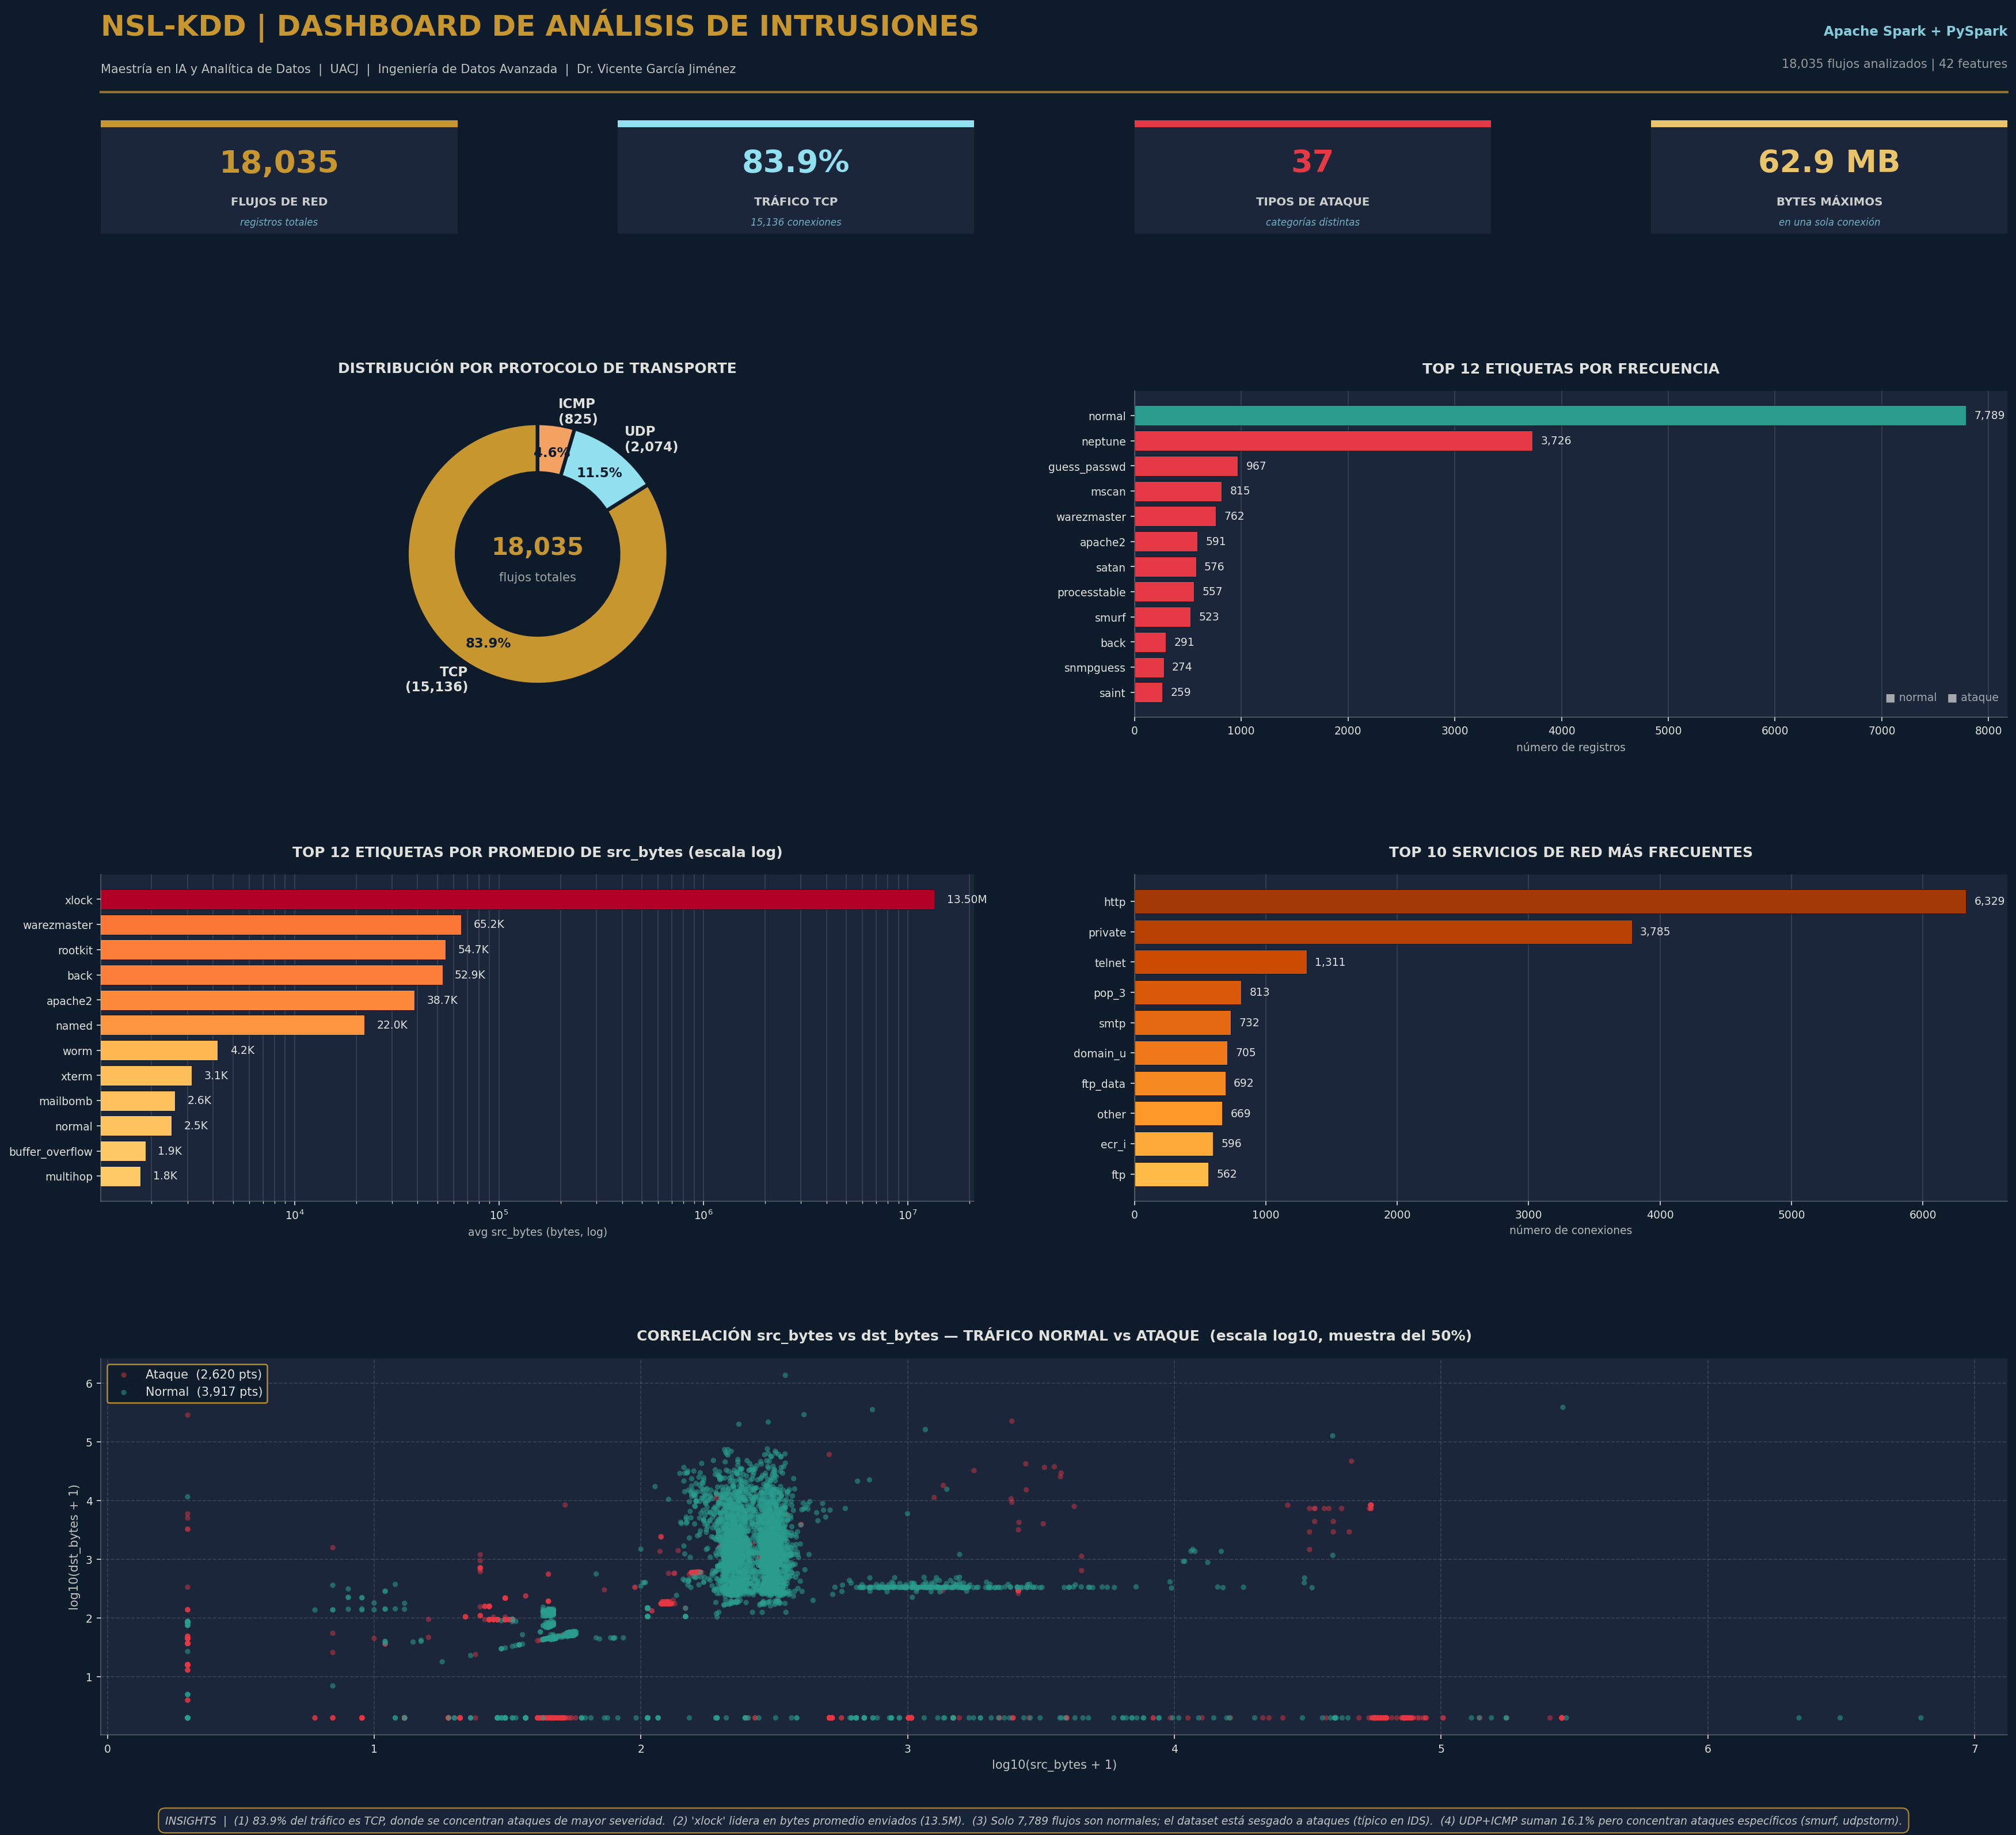

Dashboard generado correctamente.


In [17]:
# ============================================================
# DASHBOARD EJECUTIVO NSL-KDD
# Preparación de datos + visualización en una sola figura
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np

# ------------------------------------------------------------
# 1. PREPARACIÓN DE DATOS (PySpark -> pandas, agregaciones pequeñas)
# ------------------------------------------------------------

# Distribución por protocolo
pdf_protocol = (df_raw.groupBy('protocol_type').count()
    .orderBy(F.col('count').desc()).toPandas())

# Top 12 etiquetas por frecuencia
pdf_label_count = (df_raw.groupBy('label').count()
    .orderBy(F.col('count').desc()).limit(12).toPandas())

# Top 12 etiquetas por avg src_bytes (excluyendo etiquetas con avg = 0)
pdf_label_avg = (df_raw.groupBy('label')
    .agg(F.round(F.avg('src_bytes'), 2).alias('avg_src_bytes'),
         F.count('*').alias('n'))
    .filter(F.col('avg_src_bytes') > 0)
    .orderBy(F.col('avg_src_bytes').desc())
    .limit(12).toPandas())

# Top 10 servicios más frecuentes
pdf_services = (df_raw.groupBy('service').count()
    .orderBy(F.col('count').desc()).limit(10).toPandas())

# Muestra del 50% para el scatter (suficiente densidad sin saturar)
pdf_scatter = (df_raw.select('src_bytes', 'dst_bytes', 'label')
    .filter((F.col('src_bytes') > 0) | (F.col('dst_bytes') > 0))
    .sample(False, 0.5, seed=42)
    .toPandas())

# KPIs
total_flujos = df_raw.count()
total_tcp = int(pdf_protocol[pdf_protocol['protocol_type']=='tcp']['count'].iloc[0])
pct_tcp = total_tcp / total_flujos * 100
n_ataques_dist = df_raw.select('label').distinct().filter(F.col('label')!='normal').count()
max_total_bytes = df_raw.agg(F.max(F.col('src_bytes')+F.col('dst_bytes')).alias('m')).collect()[0]['m']

# ------------------------------------------------------------
# 2. PALETA UACJ Y CONFIGURACIÓN GLOBAL
# ------------------------------------------------------------
NAVY_DARK  = '#0d1b2a'
NAVY       = '#1b263b'
GOLD       = '#C8962E'
GOLD_LIGHT = '#e9c46a'
CYAN       = '#90e0ef'
WHITE      = '#e0e1dd'
RED        = '#e63946'
GREEN      = '#2a9d8f'
ORANGE     = '#f4a261'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.edgecolor': WHITE,
    'axes.labelcolor': WHITE,
    'xtick.color': WHITE,
    'ytick.color': WHITE,
    'text.color': WHITE,
    'axes.titleweight': 'bold',
})

# ------------------------------------------------------------
# 3. CONSTRUCCIÓN DE LA FIGURA (4 filas x 4 columnas)
# ------------------------------------------------------------
fig = plt.figure(figsize=(24, 22), facecolor=NAVY_DARK)
gs = fig.add_gridspec(4, 4,
    hspace=0.55, wspace=0.45,
    height_ratios=[0.45, 1.3, 1.3, 1.5],
    left=0.05, right=0.97, top=0.92, bottom=0.07)

# --- HEADER tipo magazine ---
fig.text(0.05, 0.965, 'NSL-KDD | DASHBOARD DE ANÁLISIS DE INTRUSIONES',
    fontsize=24, fontweight='bold', color=GOLD, ha='left')
fig.text(0.05, 0.945,
    'Maestría en IA y Analítica de Datos  |  UACJ  |  Ingeniería de Datos Avanzada  |  Dr. Vicente García Jiménez',
    fontsize=10, color=WHITE, ha='left', alpha=0.85)
fig.text(0.97, 0.965, 'Apache Spark + PySpark', fontsize=11, color=CYAN,
    ha='right', fontweight='bold', alpha=0.9)
fig.text(0.97, 0.948, f'{total_flujos:,} flujos analizados | 42 features',
    fontsize=10, color=WHITE, ha='right', alpha=0.65)
fig.add_artist(plt.Line2D([0.05, 0.97], [0.935, 0.935],
    color=GOLD, linewidth=2, alpha=0.7))

# --- KPI CARDS ---
def kpi_card(ax, value, label, sublabel='', accent=GOLD):
    ax.set_facecolor(NAVY)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.text(0.5, 0.62, value, fontsize=26, fontweight='bold',
            color=accent, ha='center', va='center')
    ax.text(0.5, 0.28, label, fontsize=9.5, color=WHITE,
            ha='center', va='center', alpha=0.9, fontweight='bold')
    if sublabel:
        ax.text(0.5, 0.10, sublabel, fontsize=8, color=CYAN,
                ha='center', va='center', alpha=0.75, style='italic')
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.add_patch(Rectangle((0, 0.94), 1, 0.06, facecolor=accent,
        transform=ax.transAxes, clip_on=False))

ax_k1 = fig.add_subplot(gs[0, 0])
ax_k2 = fig.add_subplot(gs[0, 1])
ax_k3 = fig.add_subplot(gs[0, 2])
ax_k4 = fig.add_subplot(gs[0, 3])
kpi_card(ax_k1, f'{total_flujos:,}',          'FLUJOS DE RED',     'registros totales',          GOLD)
kpi_card(ax_k2, f'{pct_tcp:.1f}%',            'TRÁFICO TCP',       f'{total_tcp:,} conexiones',  CYAN)
kpi_card(ax_k3, f'{n_ataques_dist}',          'TIPOS DE ATAQUE',   'categorías distintas',       RED)
kpi_card(ax_k4, f'{max_total_bytes/1e6:.1f} MB', 'BYTES MÁXIMOS',  'en una sola conexión',       GOLD_LIGHT)

# --- PANEL 1: DONUT distribución por protocolo ---
ax_donut = fig.add_subplot(gs[1, 0:2])
ax_donut.set_facecolor(NAVY_DARK)
colores_protocolo = [GOLD, CYAN, ORANGE]
wedges, texts, autotexts = ax_donut.pie(
    pdf_protocol['count'],
    labels=[f"{p.upper()}\n({c:,})" for p, c in
            zip(pdf_protocol['protocol_type'], pdf_protocol['count'])],
    colors=colores_protocolo,
    autopct='%1.1f%%',
    pctdistance=0.78, startangle=90,
    wedgeprops=dict(width=0.38, edgecolor=NAVY_DARK, linewidth=3),
    textprops=dict(color=WHITE, fontsize=11, fontweight='bold')
)
for t in autotexts:
    t.set_color(NAVY_DARK); t.set_fontweight('bold'); t.set_fontsize(11)
ax_donut.text(0, 0.05, f'{total_flujos:,}', ha='center', va='center',
    fontsize=20, fontweight='bold', color=GOLD)
ax_donut.text(0, -0.18, 'flujos totales', ha='center', va='center',
    fontsize=10, color=WHITE, alpha=0.7)
ax_donut.set_title('DISTRIBUCIÓN POR PROTOCOLO DE TRANSPORTE',
    fontsize=12, color=WHITE, pad=15)

# --- PANEL 2: TOP 12 etiquetas por frecuencia ---
ax_topcount = fig.add_subplot(gs[1, 2:4])
top_freq = pdf_label_count.iloc[::-1].reset_index(drop=True)
colores_freq = [GREEN if l == 'normal' else RED for l in top_freq['label']]
bars = ax_topcount.barh(top_freq['label'], top_freq['count'],
    color=colores_freq, edgecolor=NAVY_DARK, linewidth=0.5)
for bar, val in zip(bars, top_freq['count']):
    ax_topcount.text(bar.get_width() + max(top_freq['count'])*0.01,
        bar.get_y() + bar.get_height()/2,
        f'{int(val):,}', va='center', color=WHITE, fontsize=9)
ax_topcount.set_facecolor(NAVY)
ax_topcount.set_title('TOP 12 ETIQUETAS POR FRECUENCIA',
    fontsize=12, color=WHITE, pad=15)
ax_topcount.set_xlabel('número de registros', fontsize=9, color=WHITE, alpha=0.8)
ax_topcount.tick_params(colors=WHITE, labelsize=9)
ax_topcount.grid(axis='x', alpha=0.15, color=WHITE)
ax_topcount.set_axisbelow(True)
for s in ['top','right']: ax_topcount.spines[s].set_visible(False)
for s in ['bottom','left']:
    ax_topcount.spines[s].set_color(WHITE); ax_topcount.spines[s].set_alpha(0.3)
ax_topcount.text(0.99, 0.05, '■ normal   ■ ataque', transform=ax_topcount.transAxes,
    ha='right', fontsize=9, color=WHITE, alpha=0.7)

# --- PANEL 3: TOP 12 etiquetas por avg src_bytes (escala log) ---
ax_topavg = fig.add_subplot(gs[2, 0:2])
top_avg = pdf_label_avg.iloc[::-1].reset_index(drop=True)
norm_vals = (np.log10(top_avg['avg_src_bytes']) - np.log10(top_avg['avg_src_bytes']).min())
norm_vals = norm_vals / norm_vals.max() if norm_vals.max() > 0 else norm_vals
colores_avg = plt.cm.YlOrRd(0.3 + norm_vals * 0.6)
bars = ax_topavg.barh(top_avg['label'], top_avg['avg_src_bytes'],
    color=colores_avg, edgecolor=NAVY_DARK, linewidth=0.5)
ax_topavg.set_xscale('log')
for bar, val in zip(bars, top_avg['avg_src_bytes']):
    if val >= 1e6:   txt = f'{val/1e6:.2f}M'
    elif val >= 1e3: txt = f'{val/1e3:.1f}K'
    else:            txt = f'{val:.0f}'
    ax_topavg.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height()/2,
        txt, va='center', color=WHITE, fontsize=9)
ax_topavg.set_facecolor(NAVY)
ax_topavg.set_title('TOP 12 ETIQUETAS POR PROMEDIO DE src_bytes (escala log)',
    fontsize=12, color=WHITE, pad=15)
ax_topavg.set_xlabel('avg src_bytes (bytes, log)', fontsize=9, color=WHITE, alpha=0.8)
ax_topavg.tick_params(colors=WHITE, labelsize=9)
ax_topavg.grid(axis='x', alpha=0.15, color=WHITE, which='both')
ax_topavg.set_axisbelow(True)
for s in ['top','right']: ax_topavg.spines[s].set_visible(False)
for s in ['bottom','left']:
    ax_topavg.spines[s].set_color(WHITE); ax_topavg.spines[s].set_alpha(0.3)

# --- PANEL 4: TOP 10 servicios ---
ax_services = fig.add_subplot(gs[2, 2:4])
top_srv = pdf_services.iloc[::-1].reset_index(drop=True)
colores_srv = plt.cm.YlOrBr(np.linspace(0.4, 0.85, len(top_srv)))
bars = ax_services.barh(top_srv['service'], top_srv['count'],
    color=colores_srv, edgecolor=NAVY_DARK, linewidth=0.5)
for bar, val in zip(bars, top_srv['count']):
    ax_services.text(bar.get_width() + max(top_srv['count'])*0.01,
        bar.get_y() + bar.get_height()/2,
        f'{int(val):,}', va='center', color=WHITE, fontsize=9)
ax_services.set_facecolor(NAVY)
ax_services.set_title('TOP 10 SERVICIOS DE RED MÁS FRECUENTES',
    fontsize=12, color=WHITE, pad=15)
ax_services.set_xlabel('número de conexiones', fontsize=9, color=WHITE, alpha=0.8)
ax_services.tick_params(colors=WHITE, labelsize=9)
ax_services.grid(axis='x', alpha=0.15, color=WHITE)
ax_services.set_axisbelow(True)
for s in ['top','right']: ax_services.spines[s].set_visible(False)
for s in ['bottom','left']:
    ax_services.spines[s].set_color(WHITE); ax_services.spines[s].set_alpha(0.3)

# --- PANEL 5: SCATTER src_bytes vs dst_bytes en log-log ---
ax_sc = fig.add_subplot(gs[3, :])
pdf_scatter['src_log'] = np.log10(pdf_scatter['src_bytes'].clip(lower=1) + 1)
pdf_scatter['dst_log'] = np.log10(pdf_scatter['dst_bytes'].clip(lower=1) + 1)
is_normal = pdf_scatter['label'] == 'normal'

ax_sc.scatter(pdf_scatter[~is_normal]['src_log'], pdf_scatter[~is_normal]['dst_log'],
    c=RED, s=20, alpha=0.45, label=f'Ataque  ({(~is_normal).sum():,} pts)',
    edgecolor='none')
ax_sc.scatter(pdf_scatter[is_normal]['src_log'], pdf_scatter[is_normal]['dst_log'],
    c=GREEN, s=20, alpha=0.55, label=f'Normal  ({is_normal.sum():,} pts)',
    edgecolor='none')

ax_sc.set_facecolor(NAVY)
ax_sc.set_title(
    'CORRELACIÓN src_bytes vs dst_bytes — TRÁFICO NORMAL vs ATAQUE  (escala log10, muestra del 50%)',
    fontsize=12, color=WHITE, pad=15)
ax_sc.set_xlabel('log10(src_bytes + 1)', fontsize=10, color=WHITE, alpha=0.85)
ax_sc.set_ylabel('log10(dst_bytes + 1)', fontsize=10, color=WHITE, alpha=0.85)
ax_sc.tick_params(colors=WHITE, labelsize=9)
ax_sc.grid(alpha=0.15, color=WHITE, linestyle='--')
ax_sc.set_axisbelow(True)
for s in ['top','right']: ax_sc.spines[s].set_visible(False)
for s in ['bottom','left']:
    ax_sc.spines[s].set_color(WHITE); ax_sc.spines[s].set_alpha(0.3)
leg = ax_sc.legend(facecolor=NAVY_DARK, edgecolor=GOLD, labelcolor=WHITE,
    fontsize=10, loc='upper left', framealpha=0.9)
leg.get_frame().set_linewidth(1.2)

# --- FOOTER con insights ---
n_normal = pdf_label_count[pdf_label_count['label']=='normal']['count']
n_normal_val = int(n_normal.iloc[0]) if len(n_normal) > 0 else 0
top_attack_avg = pdf_label_avg.iloc[0]
n_udp_icmp_pct = 100 - pct_tcp

footer_text = (
    f"INSIGHTS  |  "
    f"(1) {pct_tcp:.1f}% del tráfico es TCP, donde se concentran ataques de mayor severidad.  "
    f"(2) '{top_attack_avg['label']}' lidera en bytes promedio enviados ({top_attack_avg['avg_src_bytes']/1e6:.1f}M).  "
    f"(3) Solo {n_normal_val:,} flujos son normales; el dataset está sesgado a ataques (típico en IDS).  "
    f"(4) UDP+ICMP suman {n_udp_icmp_pct:.1f}% pero concentran ataques específicos (smurf, udpstorm)."
)
fig.text(0.5, 0.025, footer_text, ha='center', va='center',
    fontsize=9, color=WHITE, alpha=0.85, style='italic',
    bbox=dict(boxstyle='round,pad=0.6', facecolor=NAVY,
              edgecolor=GOLD, linewidth=1, alpha=0.9))

fig.set_dpi(150)
plt.show()

print('Dashboard generado correctamente.')

---

## 10 - Finalización de la sesión de Spark

Es buena práctica liberar los recursos de la `SparkSession` al terminar el procesamiento, especialmente en entornos compartidos como Colab donde los recursos son limitados.


In [18]:
# ============================================================
# CIERRE DE LA SPARK SESSION
# ============================================================

spark.stop()

print('SparkSession finalizada. Recursos liberados correctamente.')


SparkSession finalizada. Recursos liberados correctamente.


---

# Conclusiones

A lo largo de esta práctica apliqué de forma integrada las nueve transformaciones más representativas del API de `DataFrame` de PySpark sobre el dataset NSL-KDD, que en su versión del Moodle contiene **18,035 flujos de red distribuidos en 42 atributos**. La cadena `select -> filter -> withColumn -> orderBy` produjo resultados verificables en cada etapa: el filtro combinado `protocol_type = 'tcp' AND src_bytes > 1000` redujo el universo a 1,552 conexiones (8.61% del total), la nueva columna `total_bytes` permitió identificar el caso extremo del ataque `xlock` con 62.9 MB transferidos en una sola conexión, y el `groupBy('label').avg('src_bytes')` reveló las 38 categorías de tráfico presentes, con `xlock` liderando con 13.5 millones de bytes promedio frente a los 2,502 bytes del tráfico `normal`. Cada paso devuelve un nuevo DataFrame, reforzando el principio de **inmutabilidad** que distingue a Spark de los frameworks tradicionales.

Desde mi rol como Sr. Associate de Application Development en banca, identifico una correspondencia directa entre estas transformaciones y los patrones que aplico sobre archivos masivos de movimientos transaccionales. El flujo proyección -> filtrado -> enriquecimiento -> agregación es exactamente el mismo que utilizo en mis procesos batch para reportes regulatorios, con la diferencia de que PySpark distribuye la ejecución mediante un DAG de transformaciones perezosas que solo se materializa al invocar una acción como `count()` o `show()`. El filtro `tcp AND src_bytes > 1000` que aplicamos en la actividad 4 es conceptualmente idéntico al que utilizo para aislar transacciones de interés por monto, canal y tipo de operación en escenarios de detección de fraude.

Un aprendizaje adicional surgió durante la ingesta: el archivo `NSL_KDD.csv` venía con un encabezado desalineado respecto a los datos, lo que sin validación previa habría producido un DataFrame con tipos incorrectos y resultados sin sentido en el filtro `src_bytes > 1000`. Detectarlo y aplicar la reasignación de nombres antes de cualquier transformación es exactamente la disciplina de control de integridad que aplico en producción: ningún archivo plano se procesa sin verificar conteo de registros, tipos y sanidad de columnas clave. Trasladar esa práctica al pipeline de PySpark fue lo que evitó el peor escenario posible en un sistema productivo: resultados engañosos pero formalmente exitosos.

---

## Referencias

- Apache Spark. (2024). *PySpark Documentation - DataFrame API*. https://spark.apache.org/docs/3.5.0/api/python/reference/pyspark.sql/dataframe.html
- Tavallaee, M., Bagheri, E., Lu, W., & Ghorbani, A. A. (2009). *A Detailed Analysis of the KDD CUP 99 Data Set*. IEEE Symposium on Computational Intelligence for Security and Defense Applications.
- Chambers, B., & Zaharia, M. (2018). *Spark: The Definitive Guide - Big Data Processing Made Simple*. O'Reilly Media.
- García Jiménez, V. (2026). *Notebooks de clase: PySparkDataTransformation01-03*. Maestría en Inteligencia Artificial y Analítica de Datos, UACJ.